C:\Users\Seamus-admin\AppData\Local\Temp\2\ipykernel_4752\3704294021.py:5: DtypeWarning: Columns (26,27,28,29,30,32,33,34,35,36,37,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df_poss = pd.read_csv(r'C:\Users\Seamus-admin\Documents\GitHub\AC-Horsens-First-Team\DNK_1_Division_2024_2025\Horsens\Horsens_possession_data.csv')


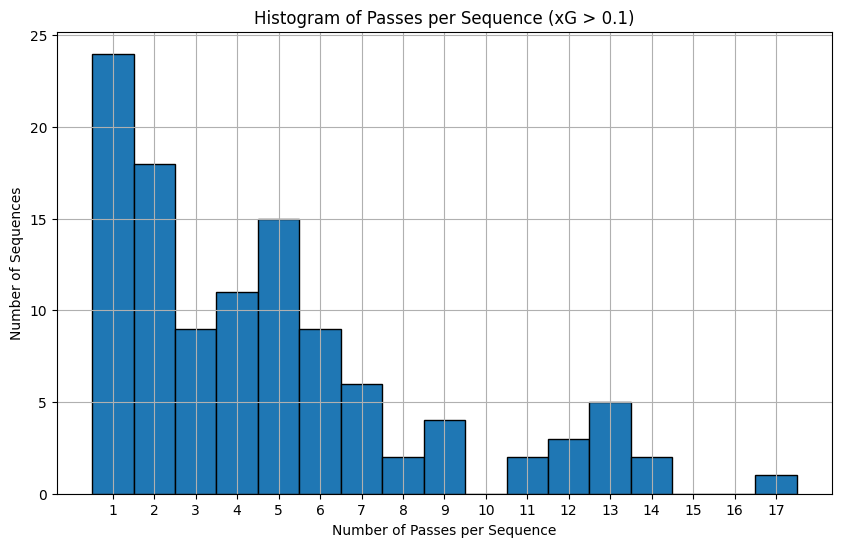

                            OLS Regression Results                            
Dep. Variable:        Goal difference   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     156.6
Date:                Mon, 28 Apr 2025   Prob (F-statistic):           2.02e-29
Time:                        08:39:10   Log-Likelihood:                -578.28
No. Observations:                 316   AIC:                             1161.
Df Residuals:                     314   BIC:                             1168.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0047      0.085      0.055

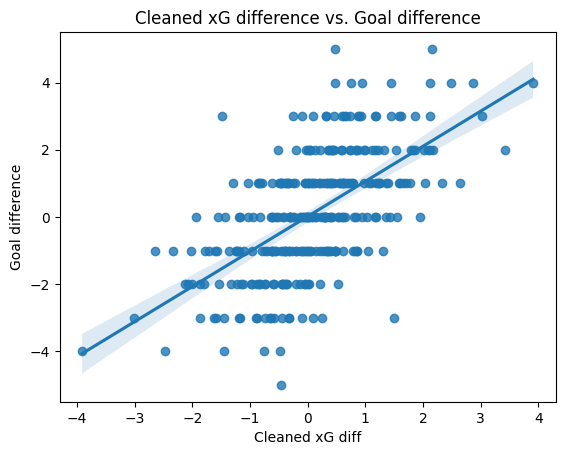

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_poss = pd.read_csv(r'C:\Users\Seamus-admin\Documents\GitHub\AC-Horsens-First-Team\DNK_1_Division_2024_2025\Horsens\Horsens_possession_data.csv')
df_passes = df_poss[(df_poss['typeId'] == 1) & (df_poss['sequence_xG'] > 0.1)]

# Step 2: Count number of passes per sequence
pass_counts = df_passes.groupby(['sequenceId']).size().reset_index(name='num_passes')

# Step 3: Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(pass_counts['num_passes'], bins=range(1, pass_counts['num_passes'].max() + 2), edgecolor='black', align='left')
plt.xlabel('Number of Passes per Sequence')
plt.ylabel('Number of Sequences')
plt.title('Histogram of Passes per Sequence (xG > 0.1)')
plt.grid(True)
plt.xticks(range(1, pass_counts['num_passes'].max() + 1))
plt.show()

df = pd.read_csv(r'C:\Users\Seamus-admin\Documents\GitHub\AC-Horsens-First-Team\DNK_1_Division_2024_2025\xg_all DNK_1_Division_2024_2025.csv')
df['label'] = df['label'] + ' '+df['date']
xg_per_match = df[['team_name', 'label', '321']]
xg_per_match = xg_per_match.groupby(['team_name', 'label']).sum().reset_index()

cleaned_xg_per_match = df[df['321'] > 0.1]
cleaned_xg_per_match = cleaned_xg_per_match[['team_name', 'label', '321']]
cleaned_xg_per_match = cleaned_xg_per_match.groupby(['team_name', 'label']).sum().reset_index()

total_xg_per_match = xg_per_match.groupby('label')['321'].sum().reset_index()
total_xg_per_match = total_xg_per_match.rename(columns={'321': 'total_match_xG'})
cleaned_total_xg_per_match = cleaned_xg_per_match.groupby('label')['321'].sum().reset_index()
cleaned_total_xg_per_match = cleaned_total_xg_per_match.rename(columns={'321': 'total_match_cleaned_xG'})

# Merge team xG with total match xG (on 'label')
xg_per_match = xg_per_match.merge(total_xg_per_match, on='label')
cleaned_xg_per_match = cleaned_xg_per_match.merge(cleaned_total_xg_per_match, on='label')
# Calculate xG difference and xG against
xg_per_match['xG_diff'] = 2 * xg_per_match['321'] - xg_per_match['total_match_xG']
xg_per_match['xG against'] = xg_per_match['total_match_xG'] - xg_per_match['321']

cleaned_xg_per_match['Cleaned xG diff'] = 2 * cleaned_xg_per_match['321'] - cleaned_xg_per_match['total_match_cleaned_xG']
cleaned_xg_per_match['Cleaned xG against'] = cleaned_xg_per_match['total_match_cleaned_xG'] - cleaned_xg_per_match['321']

# Now average xG and xG_diff per team
xg_summary = xg_per_match.groupby(['team_name','label']).agg({
    '321': 'sum',
    'xG_diff': 'sum',
    'xG against': 'sum'       # xG against
}).reset_index()
cleaned_xg_summary = cleaned_xg_per_match.groupby(['team_name','label']).agg({
    '321': 'sum',
    'Cleaned xG diff': 'sum',
    'Cleaned xG against': 'sum'       # xG against
}).reset_index()
cleaned_xg_summary = cleaned_xg_summary.rename(columns={'321': 'Cleaned xG'})

xg_summary = xg_summary.rename(columns={'321': 'xG', 'xG_diff': 'xG difference'})
xg_summary = xg_summary.merge(cleaned_xg_summary, on =['team_name','label'])

xg_summary = xg_summary.round(2)
goals = df[df['typeId'] == 16]
goals = goals[['label','team_name','typeId']]
goal_counts = goals.groupby(['label', 'team_name']).size().reset_index(name='goal_count')
total_summary = xg_summary.merge(goal_counts, on=['team_name','label'],how='outer')
total_summary['goal_count'] = total_summary['goal_count'].fillna(0).astype(int)
total_goal_per_match = total_summary.groupby('label')['goal_count'].sum().reset_index()
total_goal_per_match = total_goal_per_match.rename(columns={'goal_count': 'total goal count'})
total_summary = total_summary.merge(total_goal_per_match,on='label',how='left')
total_summary['Goal difference'] = 2 * total_summary['goal_count'] - total_summary['total goal count']


import statsmodels.api as sm

# Eksempel på relevante features

features = ['xG difference']
#features = ['xG', 'xG difference', 'xG against', 'Cleaned xG', 
#            'Cleaned xG diff', 'Cleaned xG against']

# Target: Mål scoret
target = 'Goal difference'

# Drop rækker med manglende værdier
regression_data = total_summary[features + [target]].fillna(0)

# Tilføj konstant til modellen (intercept)
X = sm.add_constant(regression_data[features])
y = regression_data[target]
model = sm.OLS(y, X).fit()
print(model.summary())

import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(data=total_summary, x='Cleaned xG diff', y='Goal difference')
plt.title("Cleaned xG difference vs. Goal difference")
plt.show()